In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("jeju_card.csv")
df.head()

,시도명,시군구명,지역구분,업종명,이용자 구분,연령대,성별,연월,이용자수,이용횟수,이용금액
0,제주도,제주시,읍면,유흥,제주도민,60대이상,여,2018-12,23,29,4240100
1,제주도,제주시,읍면,유흥,제주도민,60대이상,남,2018-12,114,190,27414000
2,제주도,제주시,읍면,유흥,제주도민,50대,여,2018-12,52,71,6848000
3,제주도,제주시,읍면,유흥,제주도민,50대,남,2018-12,259,458,91468500
4,제주도,제주시,읍면,유흥,제주도민,40대,여,2018-12,77,99,10021600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19573 entries, 0 to 19572
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   시도명     19573 non-null  object
 1   시군구명    19573 non-null  object
 2   지역구분    19573 non-null  object
 3   업종명     19573 non-null  object
 4   이용자 구분  19573 non-null  object
 5   연령대     19573 non-null  object
 6   성별      19573 non-null  object
 7   연월      19573 non-null  object
 8   이용자수    19573 non-null  int64 
 9   이용횟수    19573 non-null  int64 
 10  이용금액    19573 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 1.6+ MB


In [23]:
df['연도'] = df['연월'].str.split('-').str[0].astype('int')
df['월'] = df['연월'].str.split('-').str[1].astype('int')
df_2017_2018 = df.query('연도 in [2017, 2018]')

In [107]:
df_2017_2018

,시도명,시군구명,지역구분,업종명,이용자 구분,연령대,성별,연월,이용자수,이용횟수,이용금액,연도,월,1회당 이용금액,1회당 소비금액
0,제주도,제주시,읍면,유흥,제주도민,60대이상,여,2018-12,23,29,4240100,2018,12,146210,146210.344828
1,제주도,제주시,읍면,유흥,제주도민,60대이상,남,2018-12,114,190,27414000,2018,12,144284,144284.210526
2,제주도,제주시,읍면,유흥,제주도민,50대,여,2018-12,52,71,6848000,2018,12,96451,96450.704225
3,제주도,제주시,읍면,유흥,제주도민,50대,남,2018-12,259,458,91468500,2018,12,199713,199712.882096
4,제주도,제주시,읍면,유흥,제주도민,40대,여,2018-12,77,99,10021600,2018,12,101228,101228.282828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16702,제주도,서귀포시,도심,교통,내국인관광객,40대,남,2017-01,1891,2241,101651320,2017,1,45360,45359.803659
16703,제주도,서귀포시,도심,교통,내국인관광객,30대,여,2017-01,1033,1138,36637253,2017,1,32194,32194.422671
16704,제주도,서귀포시,도심,교통,내국인관광객,30대,남,2017-01,1570,1922,85201203,2017,1,44329,44329.450052
16705,제주도,서귀포시,도심,교통,내국인관광객,20대,여,2017-01,593,631,18802900,2017,1,29799,29798.573693


## 2017~2018년 총 이용자수, 이용횟수, 이용금액 비교

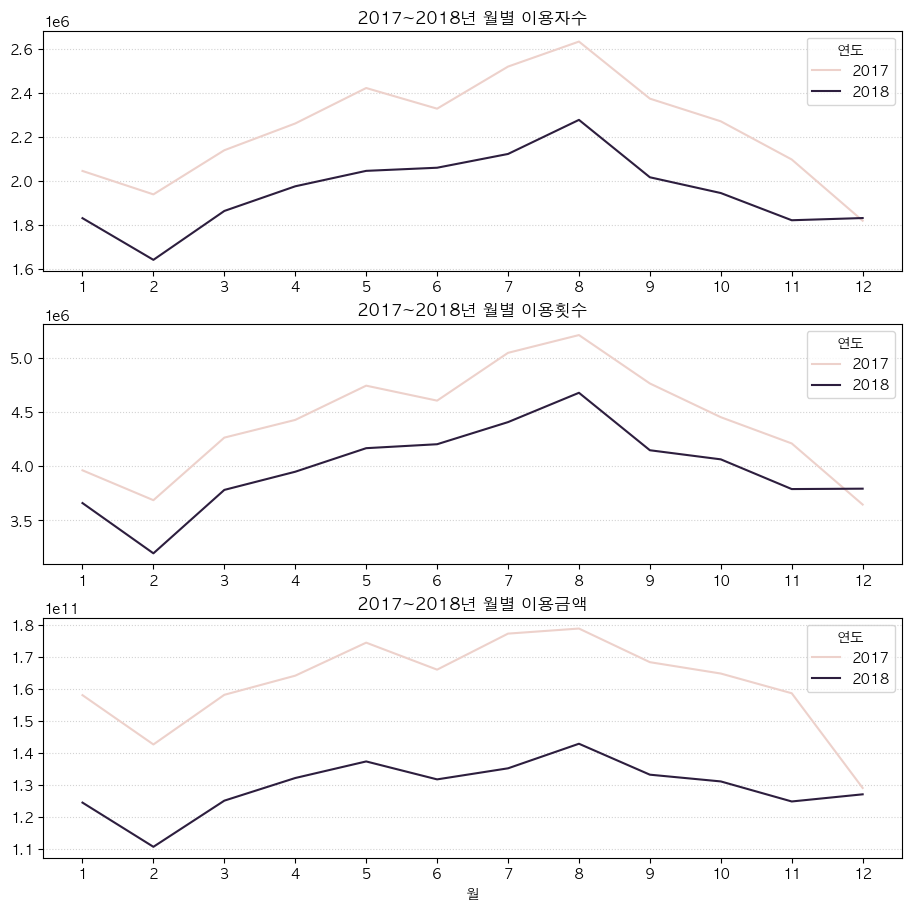

In [95]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), constrained_layout=True)

sns.set_palette('Blues_d')

# ax1 이용자수
sns.lineplot(data = df_2017_2018.query('연도 in [2017, 2018]'), x='월', y='이용자수', hue='연도', 
             estimator='sum', errorbar=None, ax=ax1)

ax1.set_title("2017~2018년 월별 이용자수")
ax1.set_xlabel("")

# ax2 이용횟수
sns.lineplot(data = df_2017_2018.query('연도 in [2017, 2018]'), x='월', y='이용횟수', hue='연도', 
             estimator='sum', errorbar=None, ax=ax2)

ax2.set_title("2017~2018년 월별 이용횟수")
ax2.set_xlabel("")

# ax3 이용금액
sns.lineplot(data = df_2017_2018.query('연도 in [2017, 2018]'), x='월', y='이용금액', hue='연도', 
             estimator='sum', errorbar=None, ax=ax3)

ax3.set_title("2017~2018년 월별 이용금액")

# ax1~3 공통가공
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(df_2017_2018['월'].unique())
    ax.set_ylabel("")
    ax.grid(axis='y', linestyle=':', color='lightgrey')

## 2017~2018년 연령대별 이용자수, 소비금액, 1회당 소비금액 비교

/var/folders/w_/f50hmtt16zvbc0ltnks44dxw0000gn/T/ipykernel_64101/1948968718.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2017_2018['1회당 소비금액'] = df_2017_2018['이용금액'] / df_2017_2018['이용횟수']


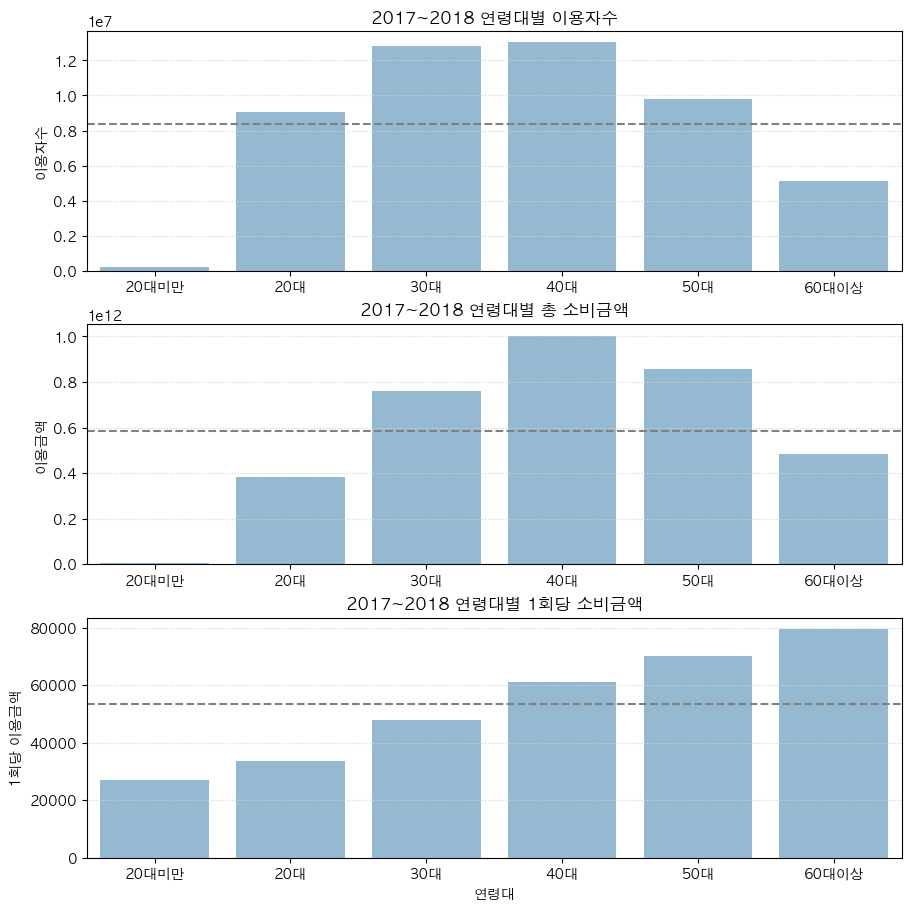

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), constrained_layout=True)

# ax1 이용자수
sns.barplot(data=df_2017_2018, x='연령대', y='이용자수', estimator='sum', ax=ax1, order=['20대미만', '20대', '30대', '40대', '50대', '60대이상'], errorbar=None)

ax1.set_title("2017~2018 연령대별 이용자수")
ax1.set_xlabel("")
ax1.axhline(y=df_2017_2018['이용자수'].sum() / 6, linestyle='--', color='grey')

# ax2 소비금액
sns.barplot(data=df_2017_2018, x='연령대', y='이용금액', estimator='sum', ax=ax2, order=['20대미만', '20대', '30대', '40대', '50대', '60대이상'], errorbar=None)

ax2.set_title("2017~2018 연령대별 총 소비금액")
ax2.set_xlabel("")
ax2.axhline(y=df_2017_2018['이용금액'].sum() / 6, linestyle='--', color='grey')

# ax3 1회당 소비금액
df_2017_2018['1회당 소비금액'] = df_2017_2018['이용금액'] / df_2017_2018['이용횟수']
sns.barplot(data=df_2017_2018, x='연령대', y='1회당 이용금액', estimator='mean', ax=ax3, order=['20대미만', '20대', '30대', '40대', '50대', '60대이상'], errorbar=None)

ax3.set_title("2017~2018 연령대별 1회당 평균 소비금액")
ax3.axhline(y=df_2017_2018['1회당 이용금액'].mean(), linestyle='--', color='grey')

# ax1~3 공통수정
for ax in [ax1, ax2, ax3]:
    ax.set_xticks(['20대미만', '20대', '30대', '40대', '50대', '60대이상'])
    ax.grid(axis='y', linestyle=':', color='lightgrey')

## 연령대별 연월별 카드 이용 추이

In [116]:
df_group = df_2017_2018.groupby(['월', '연령대'])[['1회당 이용금액']].mean()
df_group

1회당 이용금액
월  연령대                
1  20 미만  30637.762500
   20대    34113.441667
   20대미만  29211.574074
   30대    49721.766667
   40대    61739.608333
...                ...
12 20대미만  33209.079439
   30대    48838.741071
   40대    63556.227679
   50대    73571.187500
   60대이상  86197.888393

[83 rows x 1 columns]

In [121]:
df_2017_2018.query('연령대 == "60대이상"')['1회당 소비금액'].mean()

79553.36911825388

## 연령대별 어떤 업종에서 많은 금액을 지출하는지 확인

In [104]:
df_2017_2018['1회당 이용금액'] = (df_2017_2018['이용금액'] / df_2017_2018['이용횟수']).round(0).astype(int)

/var/folders/w_/f50hmtt16zvbc0ltnks44dxw0000gn/T/ipykernel_64101/1932292524.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2017_2018['1회당 이용금액'] = (df_2017_2018['이용금액'] / df_2017_2018['이용횟수']).round(0).astype(int)
